In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


DYN = ROOT / "indexes" / "wolverine_exp"

csv_path = DYN / "dapg_wolverine_graphstats_50r_b2000_sift_k100_rounds50_T24_efC80_L2_K18_fi900000_fb2000_updrandom_new_vardefault_ef2100.csv"

df = pd.read_csv(csv_path)

print(df.shape)
print(df.columns.tolist())
display(df.head())
display(df.tail())

(50, 15)
['round', 'recall', 'search_OPS', 'delete_OPS', 'insert_OPS', 'search_ms', 'delete_s', 'insert_s', 'post_active_nodes', 'post_live_edges', 'post_avg_live_degree', 'post_min_live_degree', 'post_max_live_degree', 'post_zero_live_degree_nodes', 'post_stale_edges']


,round,recall,search_OPS,delete_OPS,insert_OPS,search_ms,delete_s,insert_s,post_active_nodes,post_live_edges,post_avg_live_degree,post_min_live_degree,post_max_live_degree,post_zero_live_degree_nodes,post_stale_edges
0,0,0.9771,101.684,8684.02,940.513,9.83441,0.230308,2.12650,900000,31902494,35.4472,9,48,0,19111
1,1,0.9772,105.216,9471.94,945.492,9.50423,0.211150,2.11530,900000,30781518,34.2017,4,48,0,39544
2,2,0.9774,104.176,9626.72,1045.280,9.59917,0.207755,1.91337,900000,29814087,33.1268,2,48,0,56493
3,3,0.9771,104.597,11086.50,1026.980,9.56054,0.180399,1.94746,900000,28960552,32.1784,1,48,0,74415
4,4,0.9771,106.006,11401.10,996.067,9.43345,0.175421,2.00790,900000,28183032,31.3145,0,48,2,92615


,round,recall,search_OPS,delete_OPS,insert_OPS,search_ms,delete_s,insert_s,post_active_nodes,post_live_edges,post_avg_live_degree,post_min_live_degree,post_max_live_degree,post_zero_live_degree_nodes,post_stale_edges
45,45,0.9543,132.378,22888.0,1574.42,7.55411,0.087382,1.27031,900000,16741573,18.6017,0,48,2752,512889
46,46,0.9444,137.650,25249.7,1650.09,7.26479,0.079209,1.21205,900000,16625597,18.4729,0,48,2908,520087
47,47,0.9444,148.200,25170.5,1839.91,6.74763,0.079458,1.08701,900000,16507429,18.3416,0,48,3072,524181
48,48,0.9444,137.513,26516.4,1833.10,7.27205,0.075425,1.09105,900000,16395266,18.2170,0,48,3254,529866
49,49,0.9539,139.653,29613.0,1949.08,7.16062,0.067538,1.02612,900000,16284987,18.0944,0,48,3333,536298


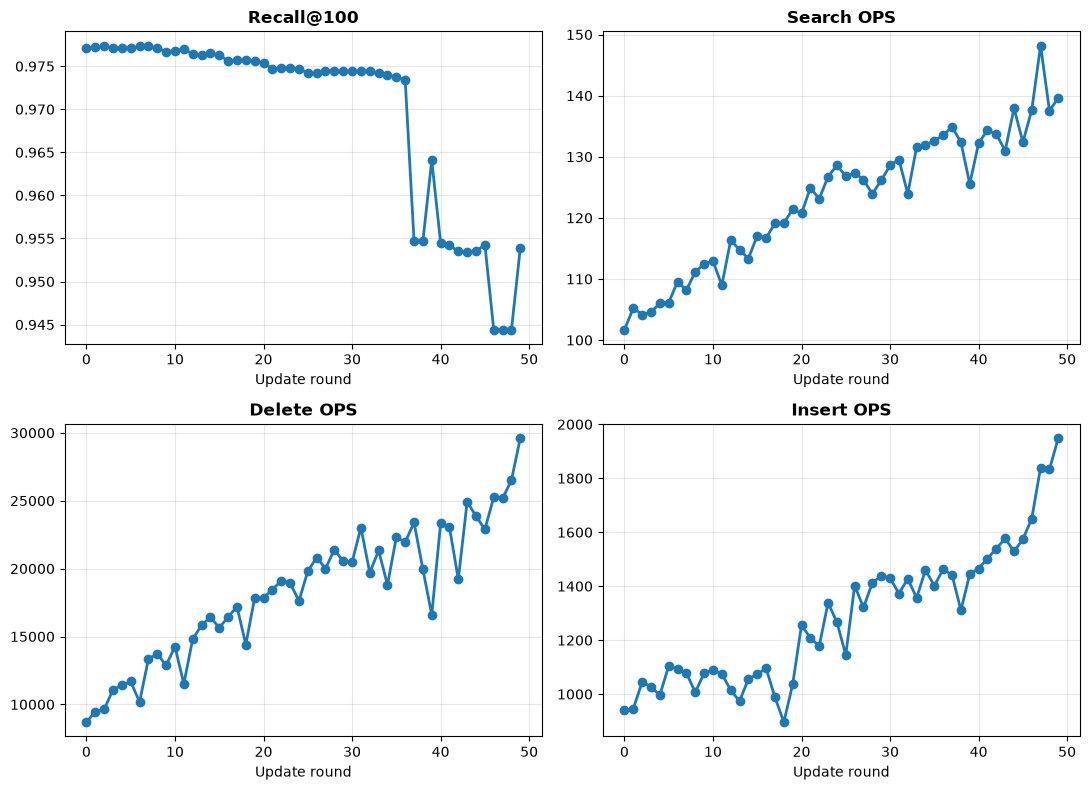

In [2]:
metrics = [
    ("recall", "Recall@100"),
    ("search_OPS", "Search OPS"),
    ("delete_OPS", "Delete OPS"),
    ("insert_OPS", "Insert OPS"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

for ax, (col, title) in zip(axes, metrics):
    ax.plot(df["round"], df[col], marker="o", linewidth=2)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Update round")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

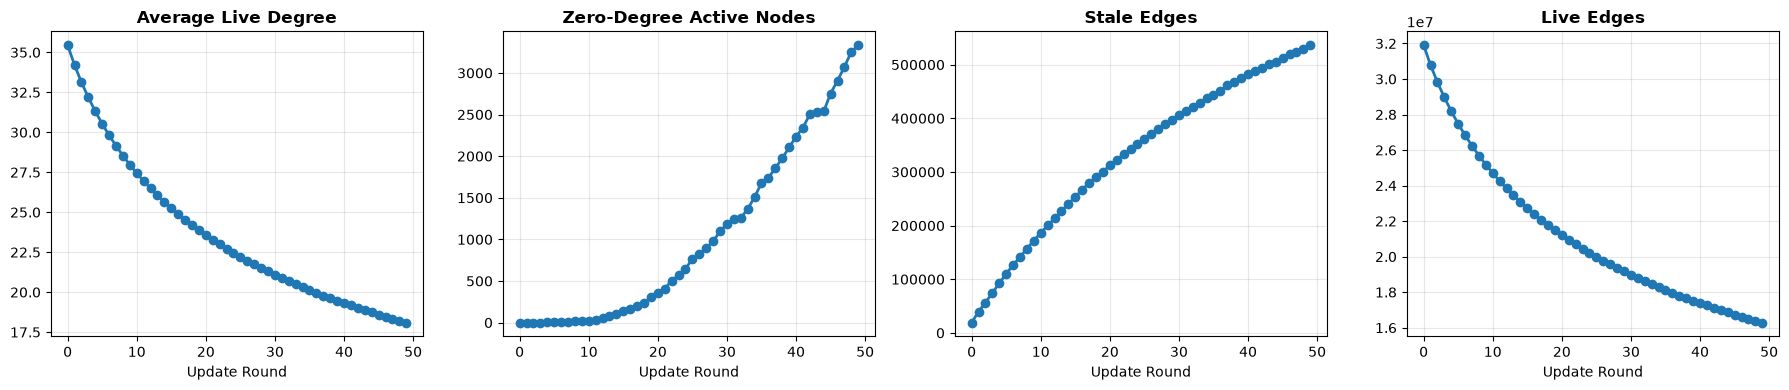

In [3]:
graph_metrics = [
    ("post_avg_live_degree", "Average Live Degree"),
    ("post_zero_live_degree_nodes", "Zero-Degree Active Nodes"),
    ("post_stale_edges", "Stale Edges"),
    ("post_live_edges", "Live Edges"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes = axes.ravel()

for ax, (col, title) in zip(axes, graph_metrics):
    ax.plot(df["round"], df[col], marker="o", linewidth=2)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Update Round")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
summary = pd.DataFrame({
    "metric": [
        "Recall@100",
        "Search OPS",
        "Delete OPS",
        "Insert OPS",
        "Avg live degree",
        "Zero-degree nodes",
        "Stale edges",
        "Live edges",
    ],
    "round_0": [
        df["recall"].iloc[0],
        df["search_OPS"].iloc[0],
        df["delete_OPS"].iloc[0],
        df["insert_OPS"].iloc[0],
        df["post_avg_live_degree"].iloc[0],
        df["post_zero_live_degree_nodes"].iloc[0],
        df["post_stale_edges"].iloc[0],
        df["post_live_edges"].iloc[0],
    ],
    "round_last": [
        df["recall"].iloc[-1],
        df["search_OPS"].iloc[-1],
        df["delete_OPS"].iloc[-1],
        df["insert_OPS"].iloc[-1],
        df["post_avg_live_degree"].iloc[-1],
        df["post_zero_live_degree_nodes"].iloc[-1],
        df["post_stale_edges"].iloc[-1],
        df["post_live_edges"].iloc[-1],
    ],
})

summary["change"] = summary["round_last"] - summary["round_0"]
display(summary)

,metric,round_0,round_last,change
0,Recall@100,9.771000e-01,9.539000e-01,-2.320000e-02
1,Search OPS,1.016840e+02,1.396530e+02,3.796900e+01
2,Delete OPS,8.684020e+03,2.961300e+04,2.092898e+04
3,Insert OPS,9.405130e+02,1.949080e+03,1.008567e+03
4,Avg live degree,3.544720e+01,1.809440e+01,-1.735280e+01
5,Zero-degree nodes,0.000000e+00,3.333000e+03,3.333000e+03
6,Stale edges,1.911100e+04,5.362980e+05,5.171870e+05
7,Live edges,3.190249e+07,1.628499e+07,-1.561751e+07


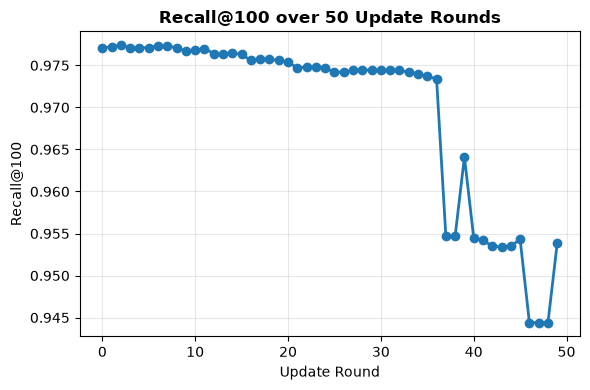

In [5]:
plt.figure(figsize=(6, 4))

plt.plot(
    df["round"],
    df["recall"],
    marker="o",
    linewidth=2
)

plt.xlabel("Update Round")
plt.ylabel("Recall@100")
plt.title("Recall@100 over 50 Update Rounds", fontweight="bold")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()